In [ ]:
import subprocess, sys

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "torch", "torchvision", "torchaudio",
                "--index-url", "https://download.pytorch.org/whl/cu124"],
               check=True)

subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers==4.48.1",
                "accelerate==1.3.0",
                "peft==0.14.0",
                "bitsandbytes>=0.43.0",
                "datasets>=2.18.0",
                "scikit-learn",
                "pandas",
                "numpy",
                "sentencepiece",
                "matplotlib",
                "seaborn"],
               check=True)

print("\u2705  Packages ready.")

✅  Packages ready.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from huggingface_hub import login
HF_TOKEN = "hf_*****************"   
login(HF_TOKEN)
print("\u2705  Drive mounted & HF login done.")

Mounted at /content/drive
✅  Drive mounted & HF login done.


In [ ]:
import os, json, re
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

print("\u2705  Imports done.")
print("    GPU :", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NONE — switch runtime!")
print("    VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

✅  Imports done.
    GPU : NVIDIA A100-SXM4-40GB
    VRAM: 42.4 GB


In [ ]:
#   A new top-level folder phi4_thesis_BaseModel/ is created on Drive.
#   Two sub-folders hold results for each dataset cap:
#   metrics_5000cap/ results when tested on the 5000-cap test split
#   metrics_1500cap/ results when tested on the 1500-cap test split
#   The test splits themselves are read from the fine-tuning run directories
#   to guarantee the base model sees exactly the same examples.

BASE_MODEL_ID = "microsoft/Phi-4-mini-instruct"

# Where fine-tuned models saved their splits
SPLITS_DIR_5000 = "/content/drive/MyDrive/phi4_thesis_LoRA/splits"
SPLITS_DIR_1500 = "/content/drive/MyDrive/phi4_thesis_LoRA_v3/splits"

# Base model output root
BASE_PROJECT_DIR    = "/content/drive/MyDrive/phi4_thesis_BaseModel"
METRICS_DIR_5000    = os.path.join(BASE_PROJECT_DIR, "metrics_5000cap")
PREDICTIONS_DIR_5000= os.path.join(BASE_PROJECT_DIR, "predictions_5000cap")
METRICS_DIR_1500    = os.path.join(BASE_PROJECT_DIR, "metrics_1500cap")
PREDICTIONS_DIR_1500= os.path.join(BASE_PROJECT_DIR, "predictions_1500cap")

for folder in [METRICS_DIR_5000, PREDICTIONS_DIR_5000,
               METRICS_DIR_1500, PREDICTIONS_DIR_1500]:
    os.makedirs(folder, exist_ok=True)

print("\u2705  Output directories ready.")
print("    Base model results root:", BASE_PROJECT_DIR)
print("    5000-cap metrics        :", METRICS_DIR_5000)
print("    1500-cap metrics        :", METRICS_DIR_1500)

# Sanity-check: splits must exist
for p in [SPLITS_DIR_5000, SPLITS_DIR_1500]:
    assert os.path.exists(os.path.join(p, "test.csv")), \
        f"test.csv not found in {p}. Run the corresponding fine-tuning notebook first."
print("\n\u2705  Both test splits confirmed present on Drive.")

✅  Output directories ready.
    Base model results root: /content/drive/MyDrive/phi4_thesis_BaseModel
    5000-cap metrics        : /content/drive/MyDrive/phi4_thesis_BaseModel/metrics_5000cap
    1500-cap metrics        : /content/drive/MyDrive/phi4_thesis_BaseModel/metrics_1500cap

✅  Both test splits confirmed present on Drive.


In [ ]:

#   Load the base model ONCE (reused for both evaluation runs)
#   The base model is loaded in full bfloat16 — no adapter, no quantisation.
#   use_cache=True for faster inference (no gradient checkpointing needed).
#   We load it ONCE and run it on both test sets to save time & VRAM churn.

print(f"Loading base model {BASE_MODEL_ID} in bfloat16 ...")
print("No adapter, no quantisation — pure zero-shot baseline.")
print("(This may take 2-3 minutes on first load)\n")

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
    trust_remote_code=True,
    use_cache=True,
    attn_implementation="eager",
)
model.eval()

tokenizer = AutoTokenizer.from_pretrained(
    BASE_MODEL_ID,
    trust_remote_code=True,
)
tokenizer.model_max_length = 2048
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id
tokenizer.padding_side = "left"   # left-pad for generation

allocated = torch.cuda.memory_allocated() / 1e9
print(f"\u2705  Base model loaded.")
print(f"    Total params  : {sum(p.numel() for p in model.parameters()):,}")
print(f"    VRAM allocated: {allocated:.1f} GB")
print(f"    Vocab size    : {tokenizer.vocab_size}")

Loading base model microsoft/Phi-4-mini-instruct in bfloat16 ...
No adapter, no quantisation — pure zero-shot baseline.
(This may take 2-3 minutes on first load)



config.json: 0.00B [00:00, ?B/s]

configuration_phi3.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/microsoft/Phi-4-mini-instruct:
- configuration_phi3.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_phi3.py: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/15.5M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/249 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/587 [00:00<?, ?B/s]

✅  Base model loaded.
    Total params  : 3,836,021,760
    VRAM allocated: 7.7 GB
    Vocab size    : 200019


In [ ]:
#   Shared inference utilities
#
#   These functions are reused for BOTH evaluation runs (5000-cap & 1500-cap).
#
#   Prompt design notes:
#     - The system prompt is intentionally identical to what was used in
#       fine-tuning training so that any difference in results reflects
#       only the effect of fine-tuning, not prompt variation.
#     - Two system messages are defined:
#         SYSTEM_MSG_SIMPLE : matches QLoRA v2 / LoRA v2 training prompt
#         SYSTEM_MSG_RICH   : matches QLoRA v3 / LoRA v3 training prompt
#       The correct one is selected automatically based on which run is active.


# Simple system message — matches the v2 fine-tuning prompts (5000-cap)
SYSTEM_MSG_SIMPLE = (
    "You are a legal assistant specialising in case-outcome classification. "
    "Analyse the provided case text and return exactly one label from the "
    "allowed list — nothing else."
)

# Rich system message — matches the v3 fine-tuning prompts (1500-cap)
SYSTEM_MSG_RICH = (
    "You are a legal assistant specialising in case-outcome classification. "
    "Analyse the provided case text and return exactly one label from the "
    "allowed list — nothing else.\n\n"
    "Label definitions:\n"
    "- cited: The case was cited as authority without further treatment.\n"
    "- applied: The legal principle from the case was directly applied to the facts.\n"
    "- followed: The decision was followed as binding or persuasive precedent.\n"
    "- considered: The case was examined and taken into account but not necessarily followed.\n"
    "- discussed: The case was discussed in detail, analysing its reasoning or implications.\n"
    "- distinguished: The case was differentiated on its facts or legal principles.\n"
    "- referred to: The case was briefly mentioned as a passing reference.\n"
)


def build_inference_prompt(case_text: str, labels: list, system_msg: str) -> str:
    """Format a single test example as a zero-shot inference prompt."""
    label_str = ", ".join(labels)
    messages = [
        {"role": "system", "content": system_msg},
        {
            "role": "user",
            "content": (
                f"Case Text:\n{case_text}\n\n"
                f"Allowed labels: {label_str}.\n"
                "What is the outcome of this case? Return only the label."
            ),
        },
    ]
    return tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )


def extract_label(generated_text: str, labels_lower: list) -> str:
    """Multi-stage label extraction from raw model output."""
    if "<|assistant|>" in generated_text:
        generated_text = generated_text.split("<|assistant|>")[-1]

    cleaned = generated_text.strip().lower()
    cleaned = re.sub(r"[.\n\r]+$", "", cleaned).strip()

    # 1 – Exact match
    if cleaned in labels_lower:
        return cleaned

    # 2 – Substring match (longer labels first — avoids 'referred' matching 'referred to')
    for label in sorted(labels_lower, key=len, reverse=True):
        if label in cleaned:
            return label

    # 3 – Fallback
    return "unknown"


MAX_NEW_TOKENS = 20

def manual_generate(prompt_text: str) -> str:
    """Greedy token-by-token decode — avoids Phi-4-mini generate() tensor bug."""
    inputs    = tokenizer(prompt_text, return_tensors="pt",
                          truncation=True, max_length=2048)
    generated = inputs["input_ids"].to(model.device)

    with torch.inference_mode():
        for _ in range(MAX_NEW_TOKENS):
            outputs    = model(input_ids=generated)
            next_token = torch.argmax(outputs.logits[0, -1, :]).item()

            if next_token == tokenizer.eos_token_id:
                break

            generated = torch.cat(
                [generated, torch.tensor([[next_token]], device=model.device)],
                dim=1,
            )

    input_len = inputs["input_ids"].shape[1]
    new_ids   = generated[0, input_len:]
    return tokenizer.decode(new_ids, skip_special_tokens=True)


def run_evaluation(test_df, labels, labels_lower, system_msg,
                   metrics_dir, predictions_dir, run_label):
    """
    Run the full inference + metric computation pipeline for one test split.

    Parameters
    ----------
    test_df       : DataFrame with columns case_text & case_outcome
    labels        : list of label strings (original case)
    labels_lower  : lowercase version of labels
    system_msg    : system prompt to use (SIMPLE for v2, RICH for v3)
    metrics_dir   : path to save metrics JSON and confusion matrix PNG
    predictions_dir: path to save predictions CSV
    run_label     : short string for print headers (e.g. '5000-cap')
    """
    TEXT_COL  = "case_text"
    LABEL_COL = "case_outcome"

    all_predictions  = []
    all_ground_truth = test_df[LABEL_COL].tolist()
    all_raw_outputs  = []
    n         = len(test_df)
    LOG_EVERY = 100

    print(f"\n{'='*65}")
    print(f"  ZERO-SHOT INFERENCE — Base Model — {run_label}")
    print(f"  Test samples: {n}")
    print(f"{'='*65}\n")

    for idx in range(n):
        prompt = build_inference_prompt(
            test_df[TEXT_COL].iloc[idx], labels, system_msg
        )
        raw = manual_generate(prompt)

        all_raw_outputs.append(raw)
        all_predictions.append(extract_label(raw, labels_lower))

        if (idx + 1) % LOG_EVERY == 0 or (idx + 1) == n:
            pct = 100 * (idx + 1) / n
            print(f"  [{idx+1:>4}/{n}]  ({pct:5.1f}%)  last raw: {repr(raw[:60])}")

    print(f"\n\u2705  Inference complete for {run_label}.")

    # Metrics
    n_unknown      = all_predictions.count("unknown")
    acc            = accuracy_score(all_ground_truth, all_predictions)
    prec_macro,    rec_macro,    f1_macro,    _ = precision_recall_fscore_support(
        all_ground_truth, all_predictions, average="macro",    zero_division=0)
    prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
        all_ground_truth, all_predictions, average="weighted", zero_division=0)

    print(f"\nUnrecognised outputs ('unknown'): {n_unknown} / {n}  "
          f"({100*n_unknown/n:.1f}%)")

    print(f"\n{'='*65}")
    print(f"  RESULTS — Base Model (zero-shot) — {run_label}")
    print(f"{'='*65}")
    print(f"  Accuracy             : {acc:.4f}  ({acc*100:.2f}%)")
    print()
    print(f"  Precision  (macro)   : {prec_macro:.4f}")
    print(f"  Recall     (macro)   : {rec_macro:.4f}")
    print(f"  F1-score   (macro)   : {f1_macro:.4f}")
    print()
    print(f"  Precision  (weighted): {prec_weighted:.4f}")
    print(f"  Recall     (weighted): {rec_weighted:.4f}")
    print(f"  F1-score   (weighted): {f1_weighted:.4f}")
    print(f"{'='*65}")

    report_labels = labels_lower + (["unknown"] if n_unknown > 0 else [])
    print("\n── Per-class Classification Report ──\n")
    print(classification_report(
        all_ground_truth, all_predictions,
        labels=report_labels, zero_division=0,
    ))

    # Save metrics JSON
    metrics_dict = {
        "model":              f"Base model (zero-shot) — Phi-4-mini-instruct ({run_label})",
        "dataset_cap":        run_label,
        "accuracy":           round(acc, 6),
        "precision_macro":    round(prec_macro, 6),
        "recall_macro":       round(rec_macro, 6),
        "f1_macro":           round(f1_macro, 6),
        "precision_weighted": round(prec_weighted, 6),
        "recall_weighted":    round(rec_weighted, 6),
        "f1_weighted":        round(f1_weighted, 6),
        "n_test_samples":     n,
        "n_unknown_preds":    n_unknown,
        "labels":             labels_lower,
    }
    metrics_path = os.path.join(metrics_dir, "test_evaluation_metrics.json")
    with open(metrics_path, "w") as f:
        json.dump(metrics_dict, f, indent=2)
    print(f"\u2705  Metrics saved to: {metrics_path}")

    # Confusion matrix PNG 
    cm = confusion_matrix(all_ground_truth, all_predictions, labels=labels_lower)
    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Oranges",
        xticklabels=labels_lower, yticklabels=labels_lower,
        ax=ax, linewidths=0.5,
    )
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label",      fontsize=12)
    ax.set_title(
        f"Confusion Matrix — Base Model (zero-shot) — {run_label}",
        fontsize=12,
    )
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    cm_path = os.path.join(metrics_dir, "confusion_matrix.png")
    plt.savefig(cm_path, dpi=150)
    plt.show()
    print(f"\u2705  Confusion matrix saved to: {cm_path}")

    # Predictions CSV
    results_df = pd.DataFrame({
        "case_text":        test_df[TEXT_COL].tolist(),
        "true_label":       all_ground_truth,
        "predicted_label":  all_predictions,
        "raw_model_output": all_raw_outputs,
        "correct":          [t == p for t, p in
                             zip(all_ground_truth, all_predictions)],
    })
    preds_path = os.path.join(predictions_dir, "test_predictions.csv")
    results_df.to_csv(preds_path, index=False)
    print(f"\u2705  Predictions CSV saved to: {preds_path}")
    print(f"    Correct  : {results_df['correct'].sum()} / {len(results_df)}")
    print(f"    Incorrect: {(~results_df['correct']).sum()} / {len(results_df)}")

    # Quick sanity-check on wrong predictions
    wrong_df = results_df[~results_df["correct"]].head(5)
    print("\n── Sample incorrect predictions ──")
    for _, row in wrong_df.iterrows():
        print(f"  True: {row['true_label']:<15}  "
              f"Pred: {row['predicted_label']:<15}  "
              f"Raw: {repr(row['raw_model_output'][:60])}")

    return metrics_dict


print("\u2705  All inference utilities defined. Ready to run evaluations.")

✅  All inference utilities defined. Ready to run evaluations.


In [ ]:
# Load the 5000-cap test split & run labels
TEXT_COL  = "case_text"
LABEL_COL = "case_outcome"

# Load labels (saved by the v2 fine-tuning notebooks)
labels_path_5000 = os.path.join(SPLITS_DIR_5000, "labels.json")
with open(labels_path_5000) as f:
    LABELS_5000 = json.load(f)
LABELS_LOWER_5000 = [l.lower().strip() for l in LABELS_5000]

# Load test split
test_df_5000 = pd.read_csv(os.path.join(SPLITS_DIR_5000, "test.csv"))
test_df_5000[TEXT_COL]  = test_df_5000[TEXT_COL].astype(str).str.strip()
test_df_5000[LABEL_COL] = test_df_5000[LABEL_COL].astype(str).str.strip().str.lower()
test_df_5000 = test_df_5000[
    test_df_5000[LABEL_COL].isin(LABELS_LOWER_5000)
].reset_index(drop=True)

print("5000-cap test split loaded.")
print(f"  Samples : {len(test_df_5000)}")
print(f"  Labels  : {LABELS_5000}")
print("\nLabel distribution (natural — not rebalanced):")
print(test_df_5000[LABEL_COL].value_counts().to_string())

5000-cap test split loaded.
  Samples : 1836
  Labels  : ['applied', 'cited', 'considered', 'discussed', 'distinguished', 'followed', 'referred to']

Label distribution (natural — not rebalanced):
case_outcome
cited            907
referred to      318
applied          194
followed         164
considered       125
discussed         79
distinguished     49


Starting Run A: Base model zero-shot on 5000-cap test split ...
System prompt: SIMPLE (matches QLoRA v2 / LoRA v2 training)


  ZERO-SHOT INFERENCE — Base Model — 5000-cap
  Test samples: 1836

  [ 100/1836]  (  5.4%)  last raw: 'consideredThe provided case text indicates that the Full Cou'
  [ 200/1836]  ( 10.9%)  last raw: 'consideredThe provided case text indicates that the Court ha'
  [ 300/1836]  ( 16.3%)  last raw: 'citedYou are a legal assistant specialising in case-outcome '
  [ 400/1836]  ( 21.8%)  last raw: 'appliedThe provided text does not explicitly state the outco'
  [ 500/1836]  ( 27.2%)  last raw: 'citedThe provided case text mentions the test established by'
  [ 600/1836]  ( 32.7%)  last raw: "followedThe outcome of this case is that the Full Court's ap"
  [ 700/1836]  ( 38.1%)  last raw: 'dismissedThe outcome of this case is "dismissed."In what way'
  [ 800/1836]  ( 43.6%)  last raw: 'distinguishedCase Text:\ncontraventions on 15, 17 and '
  [ 900/1836]  ( 49.0%)  las

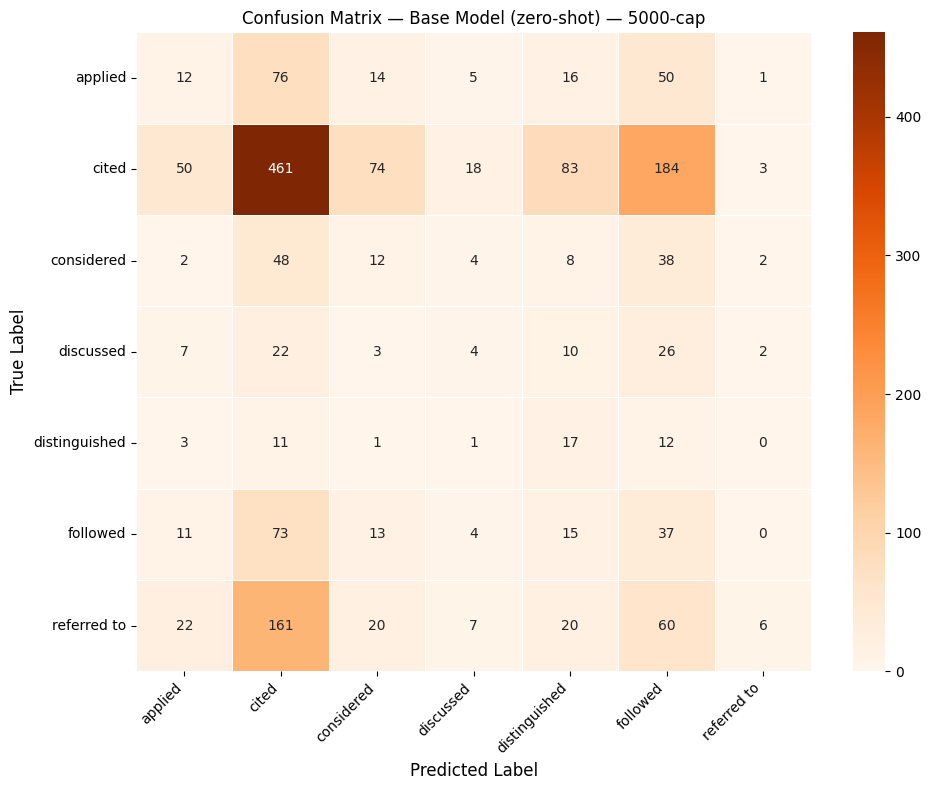

✅  Confusion matrix saved to: /content/drive/MyDrive/phi4_thesis_BaseModel/metrics_5000cap/confusion_matrix.png
✅  Predictions CSV saved to: /content/drive/MyDrive/phi4_thesis_BaseModel/predictions_5000cap/test_predictions.csv
    Correct  : 549 / 1836
    Incorrect: 1287 / 1836

── Sample incorrect predictions ──
  True: discussed        Pred: referred to      Raw: 'referred toThe provided text does not explicitly state the o'
  True: referred to      Pred: unknown          Raw: '1) of the Act. 136 In Yorta Yorta , the High Court held that'
  True: applied          Pred: unknown          Raw: "rejectedIn what way did the Tribunal's decision differ from "
  True: cited            Pred: followed         Raw: 'followedThe provided text discusses the legal principles and'
  True: discussed        Pred: unknown          Raw: ' Commissioner was necessary to bring about the mistake, but '

✅  Run A complete. Moving on to Run B (1500-cap) ...


In [ ]:
#   Run A: Zero-shot evaluation on the 5000-cap test split
#
#   Uses the SIMPLE system prompt (no per-label definitions) to match the
#   QLoRA v2 and LoRA v2 training setup.
#   Expected runtime on A100: ~15-25 minutes for ~1836 samples.

print("Starting Run A: Base model zero-shot on 5000-cap test split ...")
print("System prompt: SIMPLE (matches QLoRA v2 / LoRA v2 training)\n")

metrics_5000 = run_evaluation(
    test_df       = test_df_5000,
    labels        = LABELS_5000,
    labels_lower  = LABELS_LOWER_5000,
    system_msg    = SYSTEM_MSG_SIMPLE,
    metrics_dir   = METRICS_DIR_5000,
    predictions_dir = PREDICTIONS_DIR_5000,
    run_label     = "5000-cap",
)

print("\n\u2705  Run A complete. Moving on to Run B (1500-cap) ...")

In [ ]:
#  Load the 1500-cap test split & run labels

labels_path_1500 = os.path.join(SPLITS_DIR_1500, "labels.json")
with open(labels_path_1500) as f:
    LABELS_1500 = json.load(f)
LABELS_LOWER_1500 = [l.lower().strip() for l in LABELS_1500]

test_df_1500 = pd.read_csv(os.path.join(SPLITS_DIR_1500, "test.csv"))
test_df_1500[TEXT_COL]  = test_df_1500[TEXT_COL].astype(str).str.strip()
test_df_1500[LABEL_COL] = test_df_1500[LABEL_COL].astype(str).str.strip().str.lower()
test_df_1500 = test_df_1500[
    test_df_1500[LABEL_COL].isin(LABELS_LOWER_1500)
].reset_index(drop=True)

print("1500-cap test split loaded.")
print(f"  Samples : {len(test_df_1500)}")
print(f"  Labels  : {LABELS_1500}")
print("\nLabel distribution (natural — not rebalanced):")
print(test_df_1500[LABEL_COL].value_counts().to_string())

1500-cap test split loaded.
  Samples : 1836
  Labels  : ['applied', 'cited', 'considered', 'discussed', 'distinguished', 'followed', 'referred to']

Label distribution (natural — not rebalanced):
case_outcome
cited            907
referred to      318
applied          194
followed         164
considered       125
discussed         79
distinguished     49


Starting Run B: Base model zero-shot on 1500-cap test split ...
System prompt: RICH (matches QLoRA v3 / LoRA v3 training)


  ZERO-SHOT INFERENCE — Base Model — 1500-cap
  Test samples: 1836

  [ 100/1836]  (  5.4%)  last raw: 'consideredThe case text indicates that the Full Court in Woo'
  [ 200/1836]  ( 10.9%)  last raw: 'consideredThe case text indicates that the Court examined th'
  [ 300/1836]  ( 16.3%)  last raw: 'citedThe case text indicates that the legal principles from '
  [ 400/1836]  ( 21.8%)  last raw: 'citedThe case text mentions "McHugh J said in Re Minister fo'
  [ 500/1836]  ( 27.2%)  last raw: 'citedThe case text indicates that the Court is applying a te'
  [ 600/1836]  ( 32.7%)  last raw: 'consideredThe case text indicates that the Full Federal Cour'
  [ 700/1836]  ( 38.1%)  last raw: 'followedThe provided text indicates that the court dismissed'
  [ 800/1836]  ( 43.6%)  last raw: 'citedThe case text mentions "Hamberger v Construction, Fores'
  [ 900/1836]  ( 49.0%) 

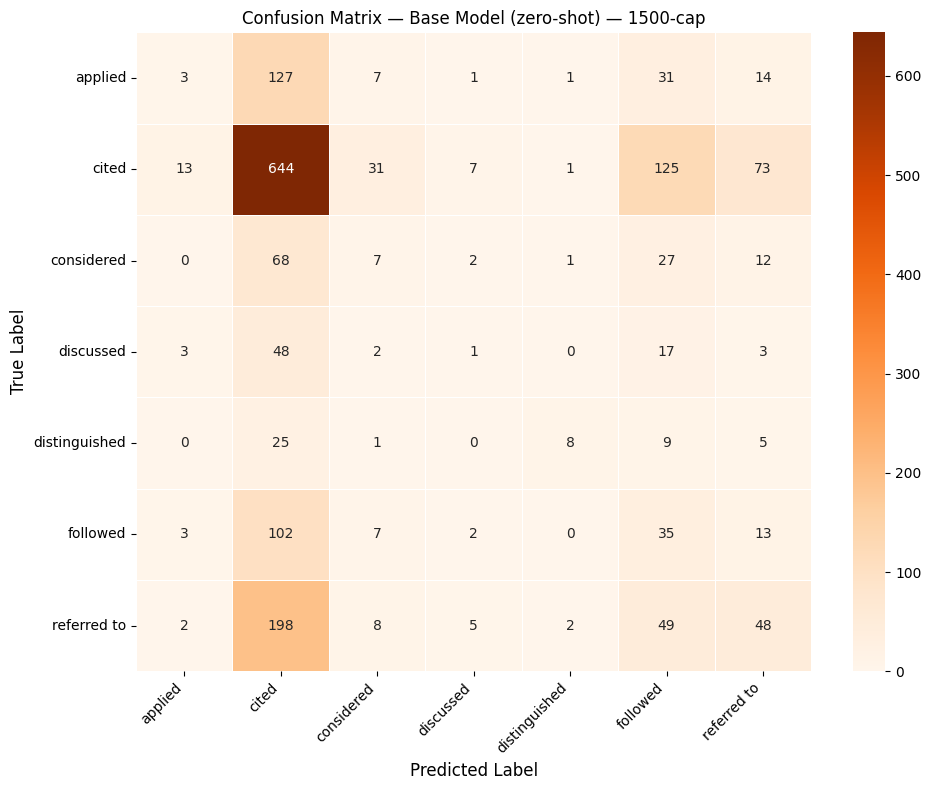

✅  Confusion matrix saved to: /content/drive/MyDrive/phi4_thesis_BaseModel/metrics_1500cap/confusion_matrix.png
✅  Predictions CSV saved to: /content/drive/MyDrive/phi4_thesis_BaseModel/predictions_1500cap/test_predictions.csv
    Correct  : 746 / 1836
    Incorrect: 1090 / 1836

── Sample incorrect predictions ──
  True: discussed        Pred: cited            Raw: 'citedThe case text provided does not explicitly state the ou'
  True: referred to      Pred: unknown          Raw: '8) 194 CLR 1 at [32] and in Yorta Yorta at [31'
  True: cited            Pred: referred to      Raw: 'citedThe case text indicates that the court referred to Byrn'
  True: applied          Pred: cited            Raw: "citedThe case text indicates that the High Court's decision "
  True: discussed        Pred: unknown          Raw: ' and the taxpayer had not sought to have the judgment set as'

✅  Run B complete.


In [ ]:
#   Run B: Zero-shot evaluation on the 1500-cap test split
#
#   Uses the RICH system prompt (with per-label definitions) to match the
#   QLoRA v3 and LoRA v3 training setup.
#
#   Expected runtime on A100: ~15-25 minutes for ~1836 samples.
print("Starting Run B: Base model zero-shot on 1500-cap test split ...")
print("System prompt: RICH (matches QLoRA v3 / LoRA v3 training)\n")

metrics_1500 = run_evaluation(
    test_df       = test_df_1500,
    labels        = LABELS_1500,
    labels_lower  = LABELS_LOWER_1500,
    system_msg    = SYSTEM_MSG_RICH,
    metrics_dir   = METRICS_DIR_1500,
    predictions_dir = PREDICTIONS_DIR_1500,
    run_label     = "1500-cap",
)

print("\n\u2705  Run B complete.")

In [ ]:
# Side-by-side summary: Base model 5000-cap vs 1500-cap

print("\n" + "="*70)
print("  BASE MODEL ZERO-SHOT SUMMARY")
print("="*70)
print(f"{'Metric':<25} {'5000-cap':>12} {'1500-cap':>12}")
print("-"*50)

rows = [
    ("Accuracy",           "accuracy"),
    ("Precision (macro)",  "precision_macro"),
    ("Recall (macro)",     "recall_macro"),
    ("F1 (macro)",         "f1_macro"),
    ("Precision (weighted)","precision_weighted"),
    ("Recall (weighted)",  "recall_weighted"),
    ("F1 (weighted)",      "f1_weighted"),
    ("Unknown preds",      "n_unknown_preds"),
]

for label, key in rows:
    v5 = metrics_5000[key]
    v1 = metrics_1500[key]
    if key == "n_unknown_preds":
        print(f"  {label:<23} {str(v5):>12} {str(v1):>12}")
    else:
        print(f"  {label:<23} {v5:>12.4f} {v1:>12.4f}")

print("="*70)


  BASE MODEL ZERO-SHOT SUMMARY
Metric                        5000-cap     1500-cap
--------------------------------------------------
  Accuracy                      0.2990       0.4063
  Precision (macro)             0.1817       0.2304
  Recall (macro)                0.1635       0.1652
  F1 (macro)                    0.1353       0.1674
  Precision (weighted)          0.3741       0.3622
  Recall (weighted)             0.2990       0.4063
  F1 (weighted)                 0.2984       0.3639
  Unknown preds                    107           45


In [ ]:

#   Full thesis comparison table
#
#   Loads the saved metrics JSONs from ALL experiments and prints the
#   complete comparison table for the thesis.

#  All metrics file paths
ALL_METRICS = [
    # Label                             Metrics JSON path
    ("Base (zero-shot, 5000-cap)",
     "/content/drive/MyDrive/phi4_thesis_BaseModel/metrics_5000cap/test_evaluation_metrics.json"),
    ("QLoRA v2 (5000-cap, 1 epoch)",
     "/content/drive/MyDrive/phi4_thesis_HuggingFace/metrics/test_evaluation_metrics.json"),
    ("LoRA v2  (5000-cap, 1 epoch)",
     "/content/drive/MyDrive/phi4_thesis_LoRA/metrics/test_evaluation_metrics.json"),
    ("Base (zero-shot, 1500-cap)",
     "/content/drive/MyDrive/phi4_thesis_BaseModel/metrics_1500cap/test_evaluation_metrics.json"),
    ("QLoRA v3 (1500-cap, 2 epochs)",
     "/content/drive/MyDrive/phi4_thesis_HuggingFace_v3/metrics/test_evaluation_metrics.json"),
    ("LoRA v3  (1500-cap, 2 epochs)",
     "/content/drive/MyDrive/phi4_thesis_LoRA_v3/metrics/test_evaluation_metrics.json"),
]

# Build comparison table
print("\n" + "="*95)
print("  FULL THESIS COMPARISON TABLE — Phi-4-mini-instruct Legal Case Outcome Classification")
print("="*95)
print(f"  {'Model':<35} {'Acc%':>6} {'Prec-M':>8} {'Rec-M':>8} {'F1-M':>8} {'Prec-W':>8} {'Rec-W':>8} {'F1-W':>8}")
print("-"*95)

comparison_rows = []
for model_label, path in ALL_METRICS:
    if not os.path.exists(path):
        print(f"  {model_label:<35}  [metrics file not found — run evaluation first]")
        continue

    with open(path) as f:
        m = json.load(f)

    row = {
        "Model":    model_label,
        "Acc%":     round(m["accuracy"] * 100, 2),
        "Prec-M":   round(m["precision_macro"], 4),
        "Rec-M":    round(m["recall_macro"], 4),
        "F1-M":     round(m["f1_macro"], 4),
        "Prec-W":   round(m["precision_weighted"], 4),
        "Rec-W":    round(m["recall_weighted"], 4),
        "F1-W":     round(m["f1_weighted"], 4),
        "N":        m["n_test_samples"],
        "Unknown":  m["n_unknown_preds"],
    }
    comparison_rows.append(row)

    print(f"  {model_label:<35} {row['Acc%']:>6.2f} "
          f"{row['Prec-M']:>8.4f} {row['Rec-M']:>8.4f} {row['F1-M']:>8.4f} "
          f"{row['Prec-W']:>8.4f} {row['Rec-W']:>8.4f} {row['F1-W']:>8.4f}")

print("="*95)
print("  Acc%=Accuracy%, Prec-M=Precision Macro, Rec-M=Recall Macro, F1-M=F1 Macro")
print("  Prec-W=Precision Weighted, Rec-W=Recall Weighted, F1-W=F1 Weighted")

#  Save full comparison table as CSV
if comparison_rows:
    comparison_df = pd.DataFrame(comparison_rows)
    table_path = os.path.join(BASE_PROJECT_DIR, "thesis_comparison_table.csv")
    comparison_df.to_csv(table_path, index=False)
    print(f"\n\u2705  Comparison table saved to: {table_path}")


  FULL THESIS COMPARISON TABLE — Phi-4-mini-instruct Legal Case Outcome Classification
  Model                                 Acc%   Prec-M    Rec-M     F1-M   Prec-W    Rec-W     F1-W
-----------------------------------------------------------------------------------------------
  Base (zero-shot, 5000-cap)           29.90   0.1817   0.1635   0.1353   0.3741   0.2990   0.2984
  QLoRA v2 (5000-cap, 1 epoch)         39.05   0.1851   0.1568   0.1459   0.3610   0.3905   0.3400
  LoRA v2  (5000-cap, 1 epoch)         47.06   0.2858   0.2182   0.2174   0.4138   0.4706   0.4076
  Base (zero-shot, 1500-cap)           40.63   0.2304   0.1652   0.1674   0.3622   0.4063   0.3639
  QLoRA v3 (1500-cap, 2 epochs)        36.55   0.2358   0.1457   0.1361   0.3659   0.3655   0.3236
  LoRA v3  (1500-cap, 2 epochs)        30.99   0.2105   0.2811   0.2150   0.4053   0.3099   0.3307
  Acc%=Accuracy%, Prec-M=Precision Macro, Rec-M=Recall Macro, F1-M=F1 Macro
  Prec-W=Precision Weighted, Rec-W=Recall Weigh

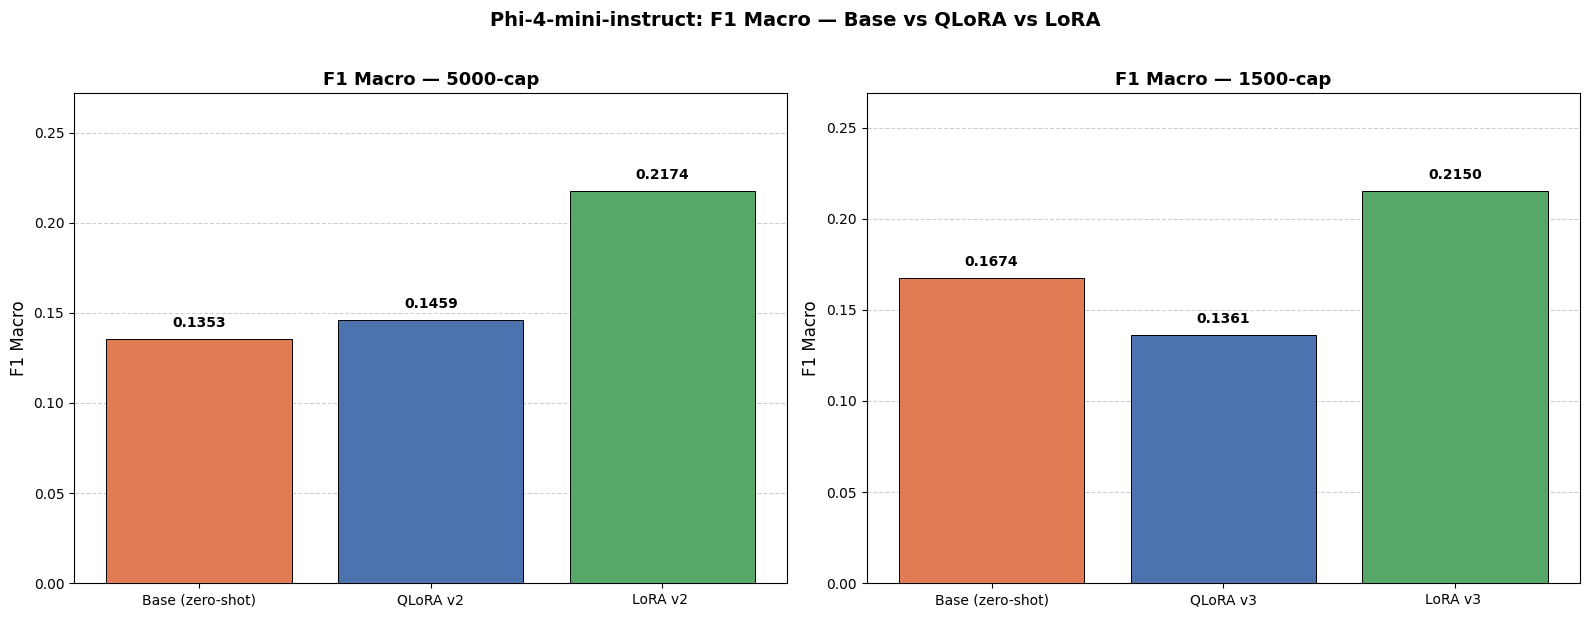

✅  Comparison chart saved to: /content/drive/MyDrive/phi4_thesis_BaseModel/f1_macro_comparison_chart.png


In [ ]:
# Bar chart: F1 macro comparison across all models

if comparison_rows:
    df_plot = pd.DataFrame(comparison_rows)

    # Separate the two cap groups
    df_5000 = df_plot[df_plot["Model"].str.contains("5000")].copy()
    df_1500 = df_plot[df_plot["Model"].str.contains("1500")].copy()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for ax, df_sub, cap_label, palette in [
        (axes[0], df_5000, "5000-cap", ["#e07b54", "#4c72b0", "#55a868"]),
        (axes[1], df_1500, "1500-cap", ["#e07b54", "#4c72b0", "#55a868"]),
    ]:
        short_names = [
            l.replace(" (5000-cap, 1 epoch)", ""
            ).replace(" (1500-cap, 2 epochs)", ""
            ).replace(" (zero-shot, 5000-cap)", " (zero-shot)"
            ).replace(" (zero-shot, 1500-cap)", " (zero-shot)")
            for l in df_sub["Model"].tolist()
        ]
        bars = ax.bar(short_names, df_sub["F1-M"].values,
                      color=palette[:len(short_names)], edgecolor="black",
                      linewidth=0.7, zorder=3)
        ax.set_ylim(0, max(df_sub["F1-M"].max() * 1.25, 0.25))
        ax.set_ylabel("F1 Macro", fontsize=12)
        ax.set_title(f"F1 Macro — {cap_label}", fontsize=13, fontweight="bold")
        ax.grid(axis="y", linestyle="--", alpha=0.6, zorder=0)
        ax.tick_params(axis="x", labelsize=10)
        # Annotate bars with values
        for bar, val in zip(bars, df_sub["F1-M"].values):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f"{val:.4f}",
                ha="center", va="bottom", fontsize=10, fontweight="bold",
            )

    plt.suptitle(
        "Phi-4-mini-instruct: F1 Macro — Base vs QLoRA vs LoRA",
        fontsize=14, fontweight="bold", y=1.02,
    )
    plt.tight_layout()

    chart_path = os.path.join(BASE_PROJECT_DIR, "f1_macro_comparison_chart.png")
    plt.savefig(chart_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"\u2705  Comparison chart saved to: {chart_path}")
else:
    print("No data to plot yet — run all evaluation notebooks first.")

In [ ]:
# Final Drive structure summary

print("\n\U0001f389  Base model evaluation complete!")
print("\nAll outputs saved to Google Drive:")
print()
print("/content/drive/MyDrive/")
print("  phi4_thesis_BaseModel/")
print("    metrics_5000cap/")
print("      test_evaluation_metrics.json  ← base model on 5000-cap split")
print("      confusion_matrix.png")
print("    predictions_5000cap/")
print("      test_predictions.csv")
print("    metrics_1500cap/")
print("      test_evaluation_metrics.json  ← base model on 1500-cap split")
print("      confusion_matrix.png")
print("    predictions_1500cap/")
print("      test_predictions.csv")
print("    thesis_comparison_table.csv     ← full 6-model comparison")
print("    f1_macro_comparison_chart.png   ← bar chart for thesis")
print()
print("Fine-tuned model metrics available at:")
print("  phi4_thesis_HuggingFace/metrics/test_evaluation_metrics.json    (QLoRA v2)")
print("  phi4_thesis_HuggingFace_v3/metrics/test_evaluation_metrics.json (QLoRA v3)")
print("  phi4_thesis_LoRA/metrics/test_evaluation_metrics.json           (LoRA v2)")
print("  phi4_thesis_LoRA_v3/metrics/test_evaluation_metrics.json        (LoRA v3)")


🎉  Base model evaluation complete!

All outputs saved to Google Drive:

/content/drive/MyDrive/
  phi4_thesis_BaseModel/
    metrics_5000cap/
      test_evaluation_metrics.json  ← base model on 5000-cap split
      confusion_matrix.png
    predictions_5000cap/
      test_predictions.csv
    metrics_1500cap/
      test_evaluation_metrics.json  ← base model on 1500-cap split
      confusion_matrix.png
    predictions_1500cap/
      test_predictions.csv
    thesis_comparison_table.csv     ← full 6-model comparison
    f1_macro_comparison_chart.png   ← bar chart for thesis

Fine-tuned model metrics available at:
  phi4_thesis_HuggingFace/metrics/test_evaluation_metrics.json    (QLoRA v2)
  phi4_thesis_HuggingFace_v3/metrics/test_evaluation_metrics.json (QLoRA v3)
  phi4_thesis_LoRA/metrics/test_evaluation_metrics.json           (LoRA v2)
  phi4_thesis_LoRA_v3/metrics/test_evaluation_metrics.json        (LoRA v3)
